# Notebook 1 – Single-channel eCMUAP

**Workflow:** load → filter → epoch → average → metrics → PSD

This notebook walks through the core eCMUAP pipeline on a single channel.  
It uses `test_emg.hdf5` (Ripple format: 32 channels × 242 580 samples @ 30 kHz).

**You will learn how to:**
1. Load a Ripple HDF5 recording and build an `EMGData` object.
2. Apply Butterworth and notch filters, and remove baseline drift.
3. Extract stimulus-aligned epochs.
4. Compute and visualise the average eCMUAP.
5. Overlay timing / amplitude metrics.
6. Compare raw vs filtered power spectral density (PSD).


## 1 · Imports & path setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ecmuap_interface.utils.trigger import Trigger
from ecmuap_interface.core.emg_data import EMGData
from ecmuap_interface.core.eCMUAP import eCMUAP
from ecmuap_interface.views.eCMUAP_view import eCMUAPView

# Resolve data file relative to this notebook
DATA_FILE = Path("../data/test_emg.hdf5")

# Inline plots, reasonable default figure size
%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (9, 3)})


## 2 · Load data

The HDF5 file contains:
- `time` – time vector (s)
- `raw 1` … `raw 32` – per-channel surface EMG (µV)
- `Tr0 ` – binary stimulus trigger (note the trailing space)


In [2]:
df = pd.read_hdf(DATA_FILE)

print(f"Shape : {df.shape[0]} samples × {df.shape[1]} columns")
print(f"Duration : {df['time'].values[-1]:.2f} s")
print(f"Sampling rate: {1 / (df['time'].values[1] - df['time'].values[0]):.0f} Hz")
df.head(3)


Shape : 242580 samples × 35 columns
Duration : 8.09 s
Sampling rate: 30000 Hz


,raw 1,raw 2,raw 3,raw 4,raw 5,raw 6,raw 7,raw 8,raw 9,raw 10,...,raw 26,raw 27,raw 28,raw 29,raw 30,raw 31,raw 32,Tr0,Tr1,time
0,13.748741,-1.999817,3.249702,9.999084,5.749474,4.999542,4.999542,1.999817,13.248787,6.249428,...,2.749748,-2.999725,8.999176,-7.999268,5.249519,-5.499496,-1.249886,-3.814051,-3.966613,0.000000
1,7.999268,0.499954,2.999725,7.749290,6.249428,-3.499680,0.999908,4.249611,13.748741,4.499588,...,5.999451,0.999908,6.749382,-5.999451,1.999817,-3.249702,-0.749931,-3.661489,-3.661489,0.000033
2,5.749474,0.499954,2.749748,7.749290,4.499588,1.749840,8.499222,9.499130,9.749107,4.749565,...,2.249794,-0.499954,6.999359,-3.749657,0.000000,-1.499863,-2.249794,-4.271737,-3.661489,0.000067


## 3 · Build Trigger and EMGData

We work with **channel 0** (physical connector channel `raw 1`) for this single-channel demo.


In [3]:
time    = df["time"].values                   # (n_samples,)
raw_ch0 = df["raw 1"].values[np.newaxis, :]   # (1, n_samples) – 2-D required

trigger = Trigger(data=df["Tr0 "].values, t=time)

# How many stimulus events were delivered?
event_idx, _, event_t = trigger.get_events()
print(f"Trigger events: {len(event_idx)}")
print(f"Stimulus rate : {1 / np.median(np.diff(event_t)):.1f} Hz")


Trigger events: 60
Stimulus rate : 10.0 Hz


In [4]:
emg = EMGData(data=raw_ch0, time=time, trigger=trigger)
print(f"EMGData  : {emg.n_channels} ch × {emg.n_samples} samples @ {emg.fs:.0f} Hz")


EMGData  : 1 ch × 242580 samples @ 30000 Hz


### 3.1 · Visualise raw trigger

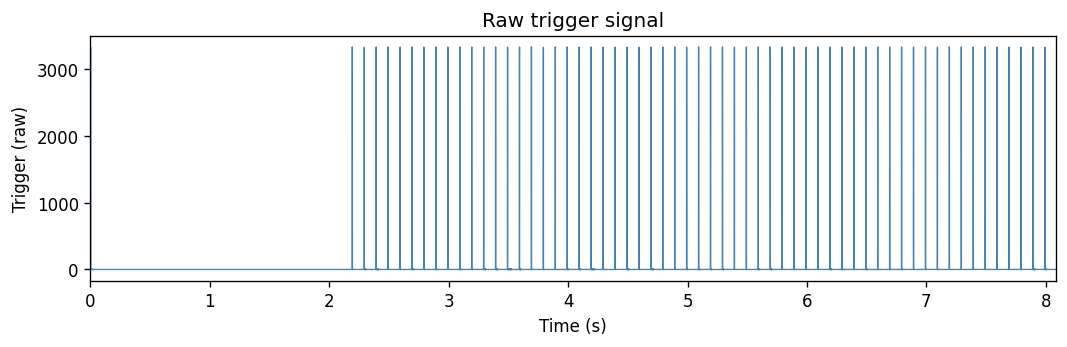

In [5]:
fig, ax = plt.subplots()
trigger.plot_raw(ax, color="steelblue", lw=0.8)
ax.set_title("Raw trigger signal")
#ax.set_xlim(0, 1.0)   # first second
plt.tight_layout()


## 4 · Filtering

Signal processing chain (applied **in-place** to `emg.data`):

| Step | Purpose |
|------|---------|
| `HPF(10)` | Remove slow DC drift / movement baseline |
| `notch(50)` | Suppress 50 Hz mains interference |
| `LPF(1000)` | Anti-alias before epoching (bandwidth: 10–1 000 Hz) |
| `remove_baseline()` | Subtract pre-stimulus rest average if a long baseline pause is detected |


In [6]:
emg.HPF(10)       # 5th-order Butterworth high-pass at 10 Hz
emg.notch(50.0)   # IIR notch at 50 Hz (Q = 30)
emg.LPF(1_000)    # 5th-order Butterworth low-pass at 1 kHz

applied = emg.remove_baseline()
print("Baseline removal applied:", applied)


Baseline removal applied: True


### 4.1 · PSD – raw vs filtered

A good filter should cut power below ~10 Hz and above ~1 kHz while  
preserving the eCMUAP frequency content (typically 50–500 Hz).


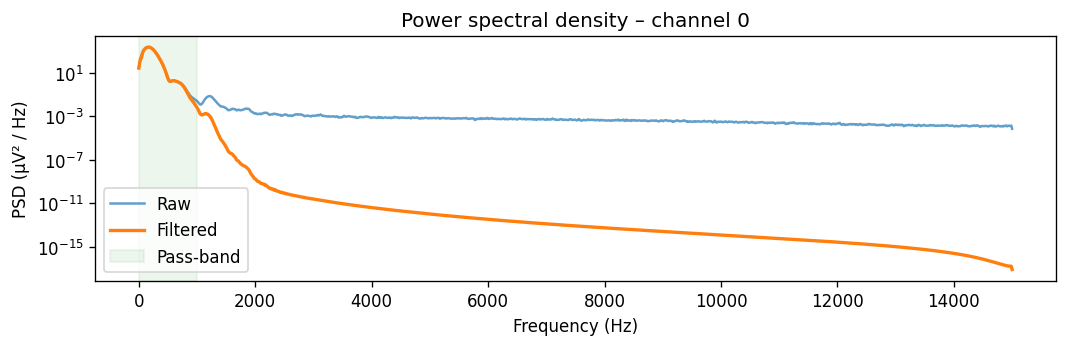

In [7]:
from scipy.signal import welch

f_raw,  psd_raw  = emg.PSD(ch_idx=0, raw=True,  nperseg=2048)
f_filt, psd_filt = emg.PSD(ch_idx=0, raw=False, nperseg=2048)

fig, ax = plt.subplots()
ax.semilogy(f_raw,  psd_raw,  label="Raw",      alpha=0.7)
ax.semilogy(f_filt, psd_filt, label="Filtered", lw=2)
ax.axvspan(10, 1000, color="green", alpha=0.07, label="Pass-band")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD (µV² / Hz)")
ax.set_title("Power spectral density – channel 0")
ax.legend()
plt.tight_layout()


## 5 · Epoching

We extract windows of ±[t_pre, t_post] around each trigger onset.  
`t_pre = 1 ms` captures the pre-stimulus baseline;  
`t_post = 15 ms` covers the full eCMUAP including late components.

Epochs at the very start/end of the recording are skipped (`skip_start/end = 3`)  
to avoid filtering edge artefacts.


In [8]:
view = eCMUAPView(emg)

T_PRE  = 1e-3   # s before stimulus
T_POST = 15e-3  # s after stimulus

epochs = view.epochs(T_PRE, T_POST, skip_start=3, skip_end=3)
# shape: (n_events, n_channels, n_samples_epoch)
print(f"Epochs array: {epochs.shape}  →  {epochs.shape[0]} events, "
      f"{epochs.shape[2]} samples / epoch")

epoch_t = np.linspace(-T_PRE, T_POST, epochs.shape[2], endpoint=False) * 1e3  # ms


Epochs array: (53, 1, 480)  →  53 events, 480 samples / epoch


### 5.1 · Overlay of all trials

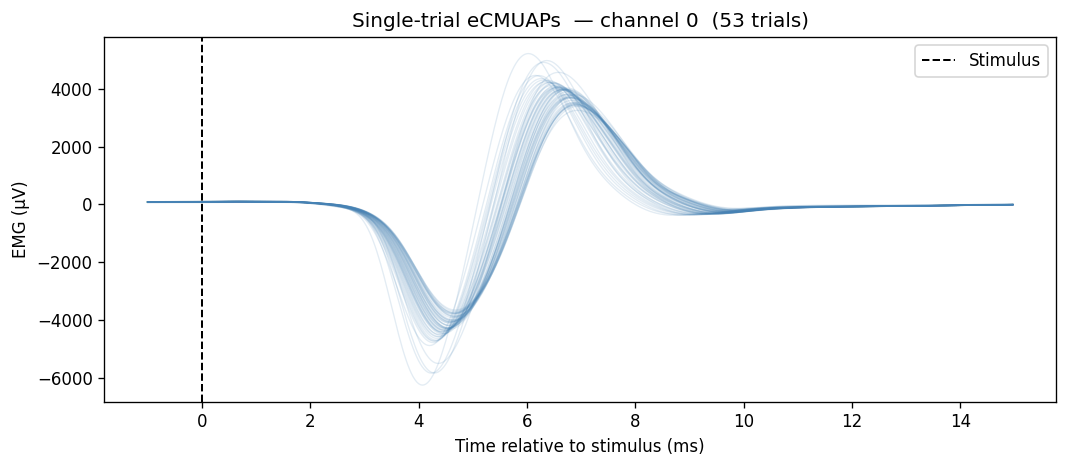

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))

for ev in range(epochs.shape[0]):
    ax.plot(epoch_t, epochs[ev, 0], color="steelblue", alpha=0.15, lw=0.8)

ax.axvline(0, color="k", ls="--", lw=1.2, label="Stimulus")
ax.set_xlabel("Time relative to stimulus (ms)")
ax.set_ylabel("EMG (µV)")
ax.set_title(f"Single-trial eCMUAPs  — channel 0  ({epochs.shape[0]} trials)")
ax.legend()
plt.tight_layout()


## 6 · Average eCMUAP

Averaging across trials reduces random noise by √N (signal-to-noise ∝ √n_trials).


In [10]:
avg = view.average(T_PRE, T_POST, skip_start=3, skip_end=3)
# shape: (n_channels, n_samples_epoch)
print("Average shape:", avg.shape)


Average shape: (1, 480)


/Users/louisregnacq/Documents/Work/in-vivo_experiment/eCMUAP-Interface/src/ecmuap_interface/views/eCMUAP_view.py:248: UserWarning: 1 epoch(s) skipped: window extends outside signal bounds (t_pre=0.001s, t_post=0.015s, signal_duration=5.894s).
  epochs = self.epochs(t_pre, t_post,


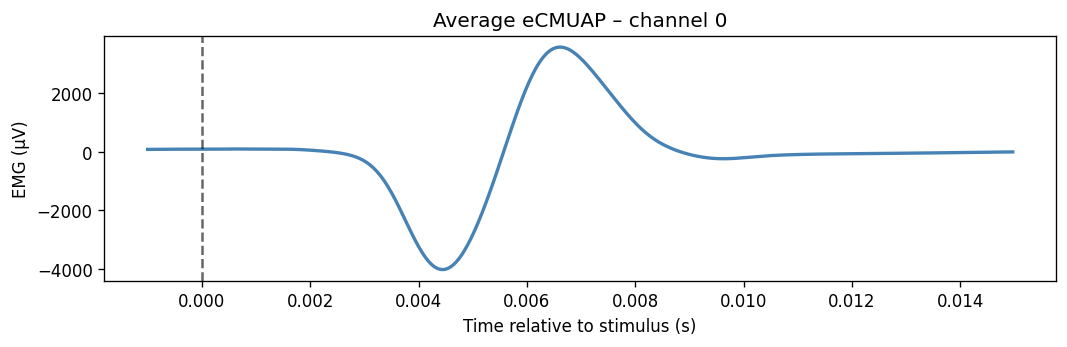

In [11]:
fig, ax = plt.subplots()
ax = view.plot_average(ch_idx=0, t_pre=T_PRE, t_post=T_POST, ax=ax,
                       color="steelblue", lw=2)
ax.set_xlabel("Time relative to stimulus (s)")
ax.set_title("Average eCMUAP – channel 0")
plt.tight_layout()


## 7 · eCMUAP metrics

Metrics are computed on the averaged waveform using a 10 % peak threshold.

| Metric | Definition |
|--------|-----------|
| `latency` | Time of first crossing of 10 % peak threshold (= eCMUAP onset) |
| `duration` | Time between first and last 10 % crossings |
| `ttmin` | Time of negative peak |
| `ttmax` | Time of positive peak |
| `peak2peak` | `max − min` amplitude |
| `rms` | Root-mean-square amplitude |


In [12]:
ec = view.average_ecmap(ch_idx=0, t_pre=T_PRE, t_post=T_POST)

summary = ec.summary()
# Convert time metrics to ms for readability
for col in ["ttmax", "ttmin", "latency"]:
    summary[col] = summary[col] * 1e3

print(summary.to_string(index=False))


       max          min   peak2peak       rms  ttmax    ttmin  latency  duration
3568.64609 -4015.629643 7584.275733 1475.0168    6.6 4.433333      3.1  0.005267


/Users/louisregnacq/Documents/Work/in-vivo_experiment/eCMUAP-Interface/src/ecmuap_interface/views/eCMUAP_view.py:248: UserWarning: 1 epoch(s) skipped: window extends outside signal bounds (t_pre=0.001s, t_post=0.015s, signal_duration=5.894s).
  epochs = self.epochs(t_pre, t_post,


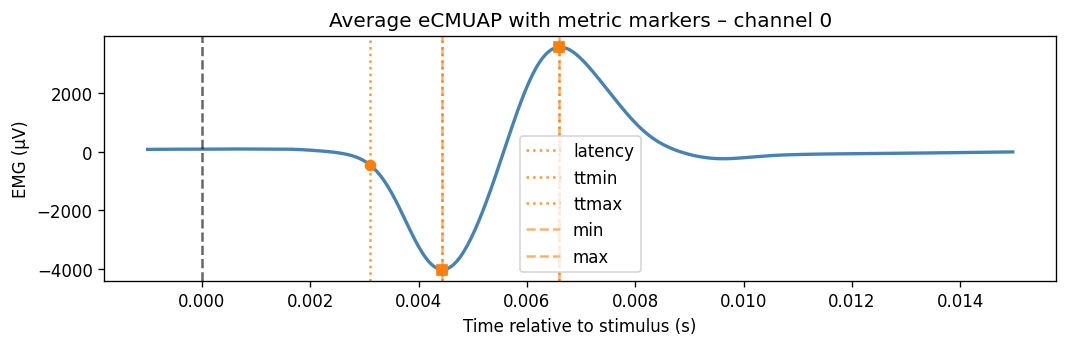

In [13]:
fig, ax = plt.subplots()
ax = view.plot_average(ch_idx=0, t_pre=T_PRE, t_post=T_POST, ax=ax,
                       color="steelblue", lw=2)
view.plot_metrics_markers(ch_idx=0, t_pre=T_PRE, t_post=T_POST,
                          metrics=["latency", "ttmin", "ttmax", "min", "max"],
                          ax=ax, color="C1")
ax.set_xlabel("Time relative to stimulus (s)")
ax.set_title("Average eCMUAP with metric markers – channel 0")
plt.tight_layout()


## 8 · Summary

| What we covered | API used |
|----------------|---------|
| Load Ripple HDF5 | `pd.read_hdf` |
| Build trigger | `Trigger` |
| Build EMGData | `EMGData` |
| Filter signal | `emg.HPF / LPF / notch / remove_baseline` |
| Extract epochs | `eCMUAPView.epochs` |
| Compute average | `eCMUAPView.average` |
| Compute metrics | `eCMUAP.summary()` |
| Plot with markers | `eCMUAPView.plot_average / plot_metrics_markers` |

**Next:** [Notebook 2](02_HD_emg.ipynb) – HD-EMG spatial analysis (interpolation, spatial filtering, amplitude maps).
